# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 66     |  |
| :-------------|:-------------|
| Lars Mulder | 6546862 |
| John Sia| 6223494 |

In [335]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

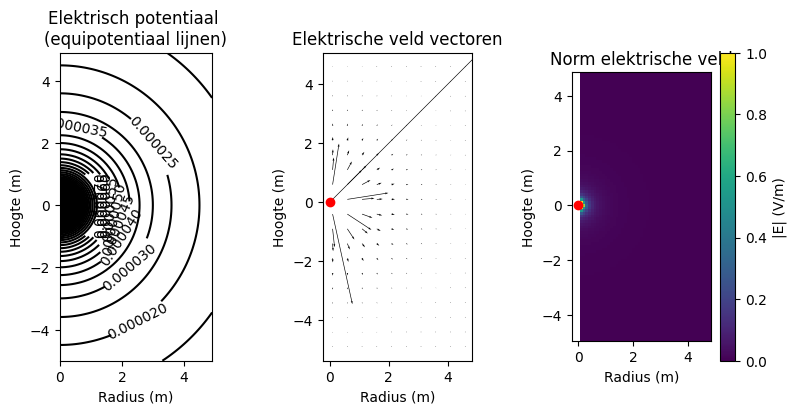

In [336]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

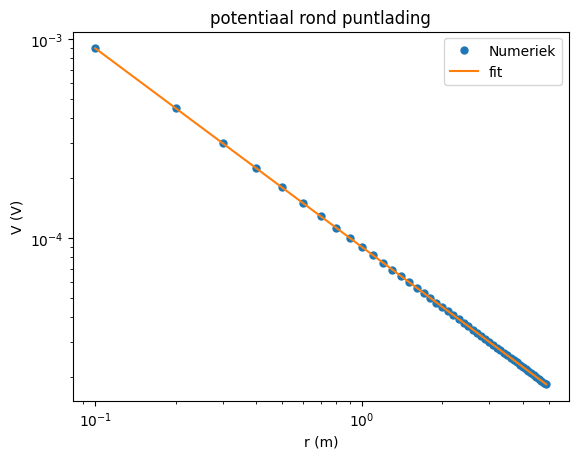

Exponent n ≈ -1.000
Index die correspondeert met z = 0m : 50


In [337]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 

# index waar z = 0
idx_z0 = np.argmin(np.abs(z - 0))

# r > 0 (log(0) kan niet)
r_nonzero = r[1:]
V_slice = V[idx_z0, 1:]

# fitten
def fitfunctie(r, A, n):
    return A * r**n

val, cov = curve_fit(fitfunctie, r_nonzero, V_slice)
A_fit = val[0]
n_fit = val[1]

# plotten
plt.figure()
plt.loglog(r_nonzero, V_slice, '.', label="Numeriek", markersize= 10)
plt.loglog(r_nonzero, fitfunctie(r_nonzero, A_fit, n_fit),label="fit")
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.title("potentiaal rond puntlading")
plt.legend()
plt.show()

# waarden printen
print(f"Exponent n ≈ {n_fit:.3f}")
print(f"Index die correspondeert met z = 0m : {idx_z0}")

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

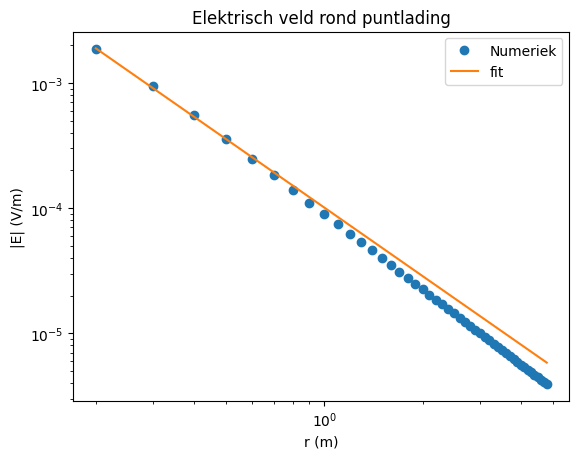

Exponent van het elektrisch veld ≈ -1.821


In [338]:
# index waar z = 0
idx_z0 = np.argmin(np.abs(z - 0))

# r > 0 (log(0) kan niet)
r_E = r_for_E
E_slice = normE[idx_z0, :]

r_E_nonzero = r_E[1:]
E_nonzero = E_slice[1:]


# fitten
def fitfunc(r, A, n):
    return A * r**n

val, cov = curve_fit(fitfunc, r_E_nonzero,E_nonzero)

A_fit = val[0]
n_fit = val[1]

# plotten
plt.figure()
plt.loglog(r_E_nonzero, E_nonzero, 'o', label="Numeriek")
plt.loglog(r_E_nonzero,fitfunc(r_E_nonzero, A_fit, n_fit),label="fit")
plt.xlabel("r (m)")
plt.ylabel("|E| (V/m)")
plt.title("Elektrisch veld rond puntlading")
plt.legend()
plt.show()


# waarde van exponent
print(f"Exponent van het elektrisch veld ≈ {n_fit:.3f}")


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [339]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

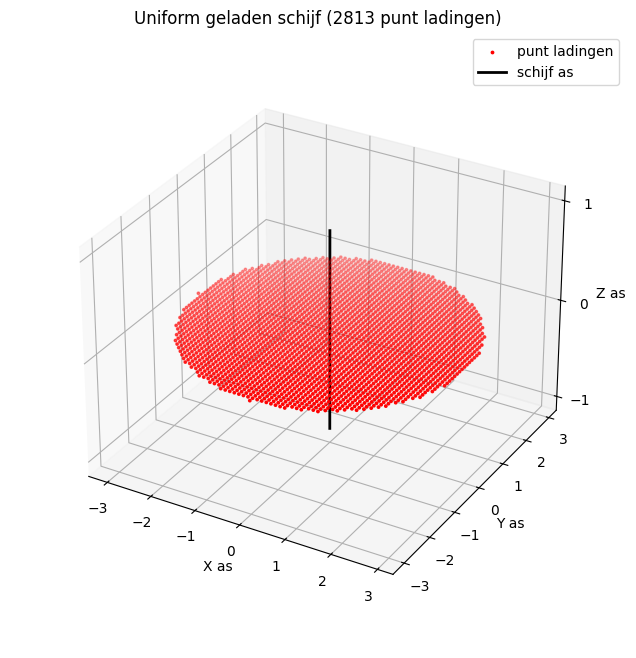

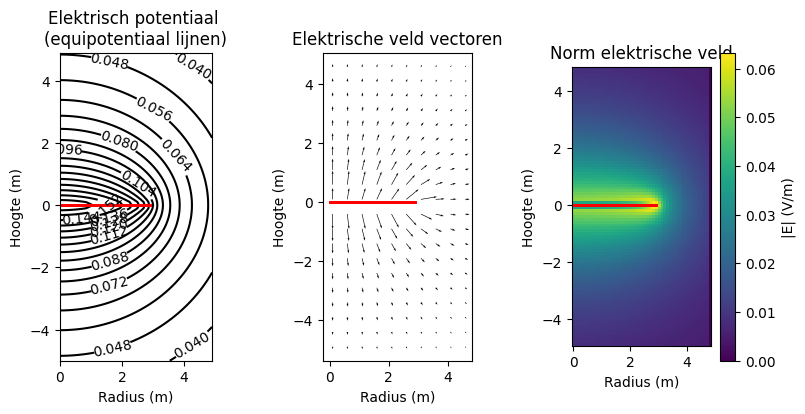

In [340]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. The disk radius is the boundary that all charges exist within. In other words, it the area of the total charge. If the radius becauses 0, the simulation displace an empty space, however there is an exist of a charge. The only plussible answer will be that the charge has been squezzed so much so that its can be regarded as a point charge ( like a singularity due to the density been compressed in a very small surface area). 


2. Changing the gridstep, changes the points alignment and the space inbetween each point. Increasing the value, results in not so aligned point with wider spacing inbetween, whiles decreasing the gridstep shows a space with charges closer to each other which are more aligned.  Based on that, we believe the gridstep is related to how accurate the electric field is calculated. Using a small value, allows python to calculate more points. This significantly result in a more accurate electric field.

3. The codes we are going to inspect are us follow:
- z_coord_DisK: This code is used to situate the disk at the verticle line. Telling it where its origin should be at the z-axis. Changes made to this code result in the shift of the disk's maximum and minimum values(shift in the highest potential value). 

- inter_charge_distance : This code spaces the individual charges in the space to form the disk. Changing the code to a smaller value result in a particles that are very closer to each other. Making the disk become like a uniform object (We changed it to 0.01 and it looked like one big disk). Enlarging the value will result in scattered points.  The disk would not be no more homogeneous .



#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [341]:
# The equation used to find a charge's density is; The total amount of charges divided by the area where the charges are situated.  
#Since we are dealing with disk, the total area can be calculated using the equation used to find the area of a circle: pI* the radius raised to the power two.
def Area (r):
    y=np.pi*((r)**2)
    return(y)

Area_value= Area(disk_radius) # The radius is the same as the disk's radius.

# The total charge is the total number of points (Each point represents a charge) on the disk times the the charge per point ( the charge that one point has). 
total_charge = number_point_charges_on_disk*charge_one_point

#Based on the area and the total charge, we now calculate the charge density.
sigma= total_charge/ Area_value

#Now we print the values
print(f"Number of points on disk: {number_point_charges_on_disk}")
print(f"Surface charge density (sigma): {sigma:.4e} C/m^2")

Number of points on disk: 2813
Surface charge density (sigma): 9.9490e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

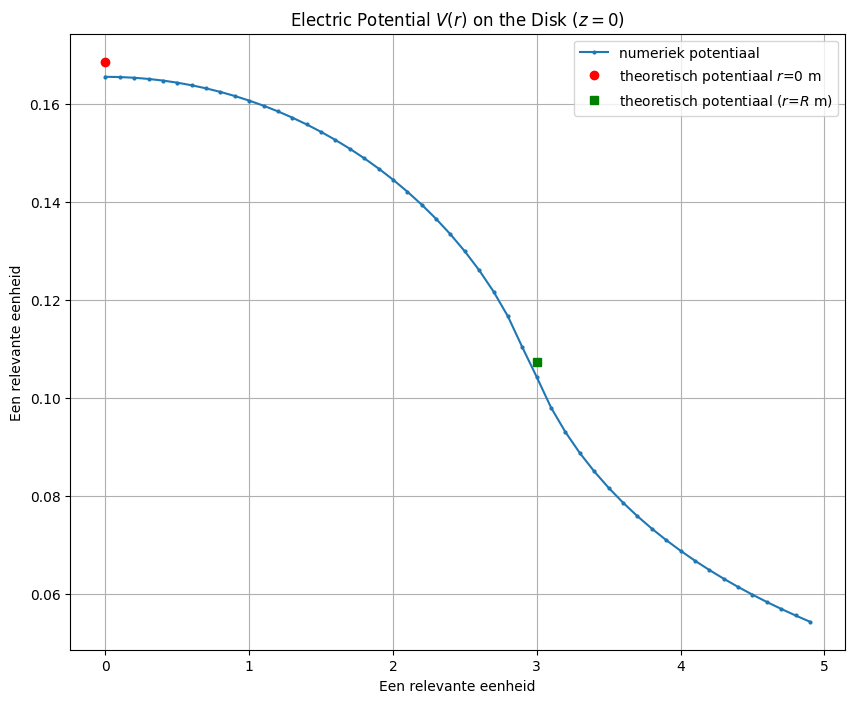

In [342]:
#The equation for the potential is: sigma(de charge density)*the radius divided by 2 times the permittivity of a vacuum.
idx_z_zero = np.argmin(np.abs(z))

V_at_z_zero =V[idx_z_zero,:]

V_0 = (sigma*disk_radius)/(2*epsilon0) # potentiaal op r = 0

V_R = (sigma*disk_radius)/(np.pi*epsilon0) # potentiaal op de straal van de schijf
r_R = (disk_radius)  # straal van de schijf

#Now we visualize it
plt.figure(figsize=(10,8))
plt.title(f"Electric Potential $V(r)$ on the Disk ($z=0$)")

plt.plot(r, V_at_z_zero, "o-",markersize=2, label="numeriek potentiaal")
plt.plot(0, V_0, "ro", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "gs", label=f"theoretisch potentiaal ($r$=$R$ m)")

plt.legend()
plt.grid(True)
plt.xlabel("Een relevante eenheid")
plt.ylabel("Een relevante eenheid")
plt.show()


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


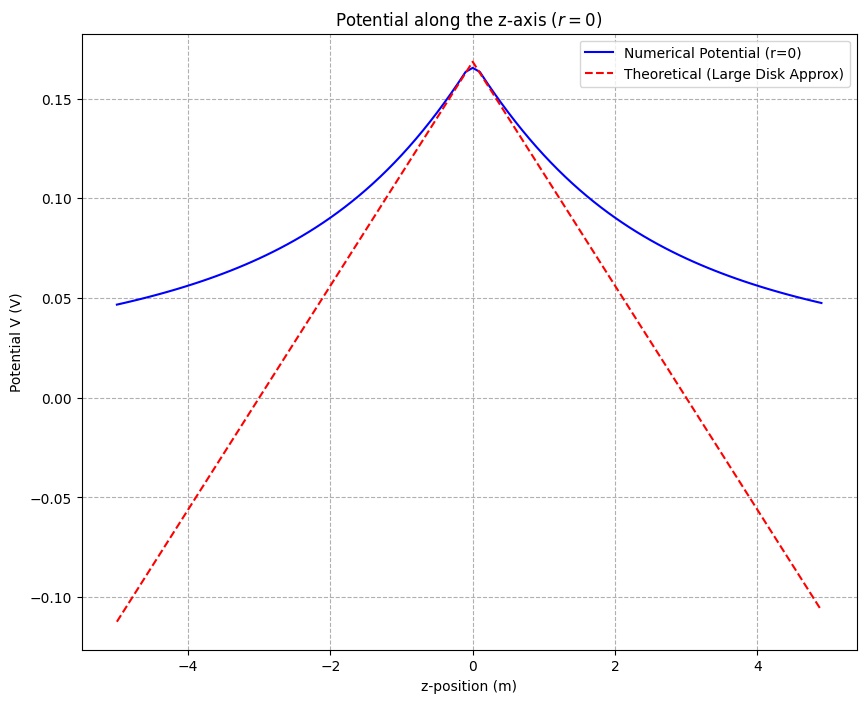

In [343]:
#Here, we calculate the  potential distribution the along the z axis.


idx_r_zero =np.argmin(np.abs(r)) # This finds the origin of  the radius. Which is 0.
V_numerical_z =V[:,idx_r_zero] # We used slicing here to find the potential values along the z-axis.

#Calculating the theoretical potential
V_theoretical_z=(sigma/(2*epsilon0))*(disk_radius-np.abs(z))

#Plotting for visualization and inspection. 
plt.figure(figsize=(10,8))
plt.plot(z,V_numerical_z, color='b', label ='Numerical Potential (r=0)')
plt.plot(z, V_theoretical_z, 'r--', label="Theoretical (Large Disk Approx)")

plt.title("Potential along the z-axis ($r=0$)")
plt.xlabel("z-position (m)")
plt.ylabel("Potential V (V)")
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig("vraag2d_plot.png")
plt.show()

##### Analysing the graphic
What becames clear from the graph is that both the theoretical and the numerical peak at the z=0. That is an indication that the approximation is correct. However, further inspection shows how the theoretical value drops faster than the numerical value. This is due to assume used to calculate the theorical potential (The assume is the space is  infinite). 

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

(98,)
(98,)


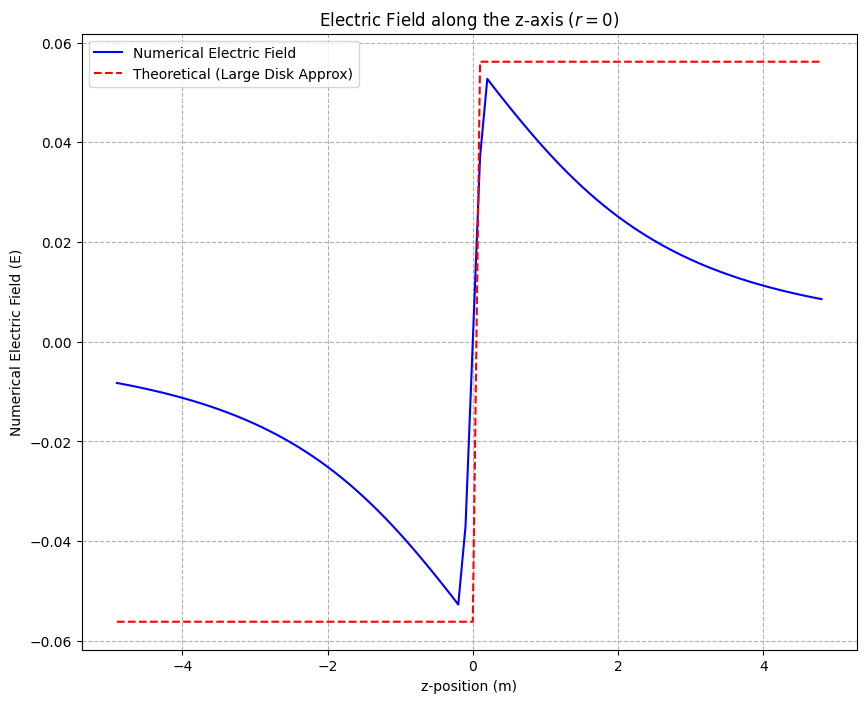

In [344]:
idx_r_zero =np.argmin(np.abs(r)) # This finds the origin of  the radius. Which is 0.
E_numerical_z =Ez[:,idx_r_zero] # We used slicing here to insulate the values along the z-axis.
z_plot = z[1:-1] 

Theoretical_E_F = np.sign(z_plot)*((sigma/(2*epsilon0)))

print(z_plot.shape)
print(E_numerical_z.shape)


plt.figure(figsize=(10,8))
plt.plot(z_plot,E_numerical_z, color='b', label ='Numerical Electric Field')
plt.plot(z_plot,Theoretical_E_F, 'r--', label="Theoretical (Large Disk Approx)")

plt.title("Electric Field along the z-axis ($r=0$)")
plt.xlabel("z-position (m)")
plt.ylabel("Numerical Electric Field (E)")
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig("vraag2e_plot_nieuwe_straal.png")
plt.show()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f
1) Inspecting the graph shows that the blue line (Electric Field), matches the theoretical field of the infinite plane when it is closer to the surface of the disk. Comparing the electric field at the edge with the ones closer to the center, the center points simples be have a much stronger fields than the ones at the edge of the disk. Due to the strong fields at the center, the edges vanishes and makes the plane an infinite flat plane. 


2) 
 - Effect of distance: As we move further away from the origin on the z_as, the numerical electric field of the disk smoothly curves back down towards zero whereas the theoretical line remains constant (a horizontal line). This is due to the theoretical approach having an infinite amount of charge spreading over an infinite area with a field strength that does not get weak. The numerical field on the other hand does the opposite. it has a finite amount and weakens as it moves away from the origin. This makes the electric field decay towards 0. 

 - The peaks: The theoretical value has a much higher peak than the numerical one. This is because the theoretical fields have an infinite amount of charges that result in a much stronger electric field than the numerical one. Also the theoretical approach has a very small steps (z=0.000....1).  This makes the points be more closer to each other. This generate a stronger electric field. The more points, the more stronger the E-field. And the closer the points, the stronger the E-field.
 



#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

##### Antwoorden 2g
- Changing the disk radius increases the number of points (charges) that can be simulated. This makes the numerical electric field strong and pushes the peak closer to that of the theoretical model. 

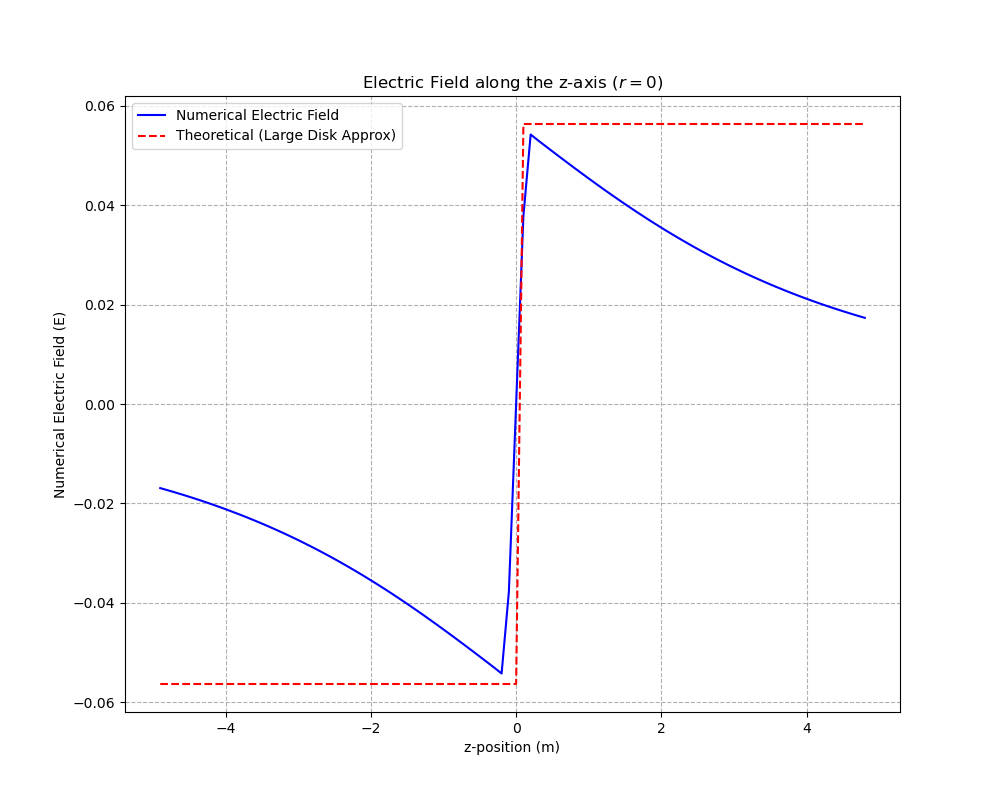

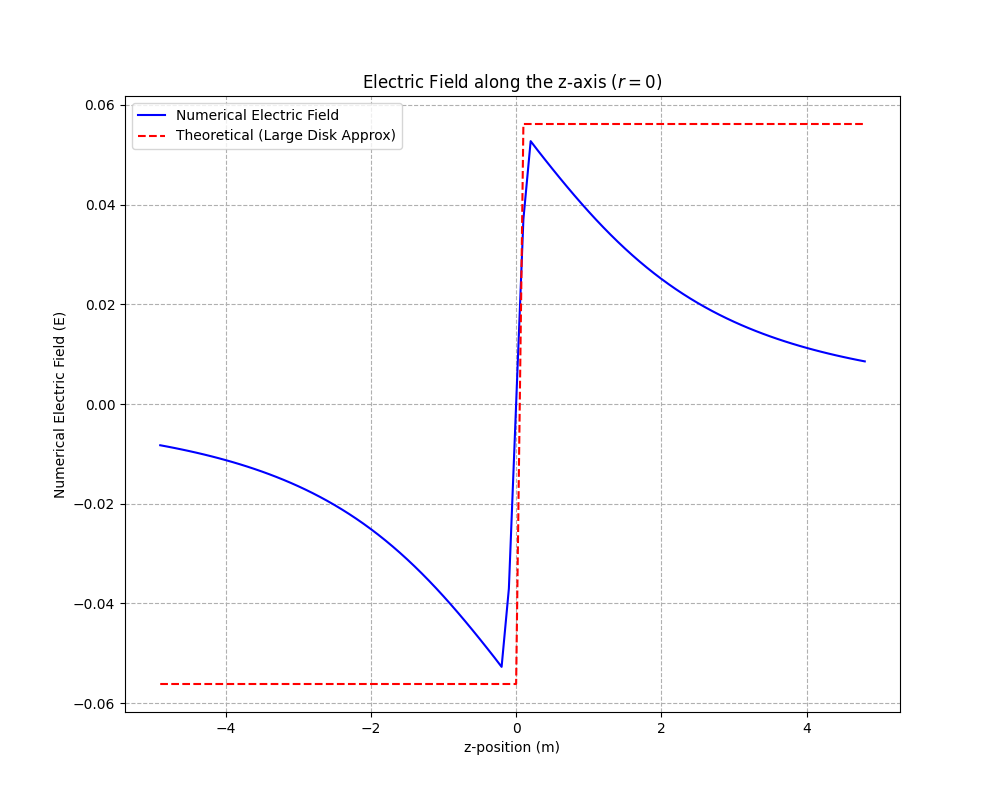

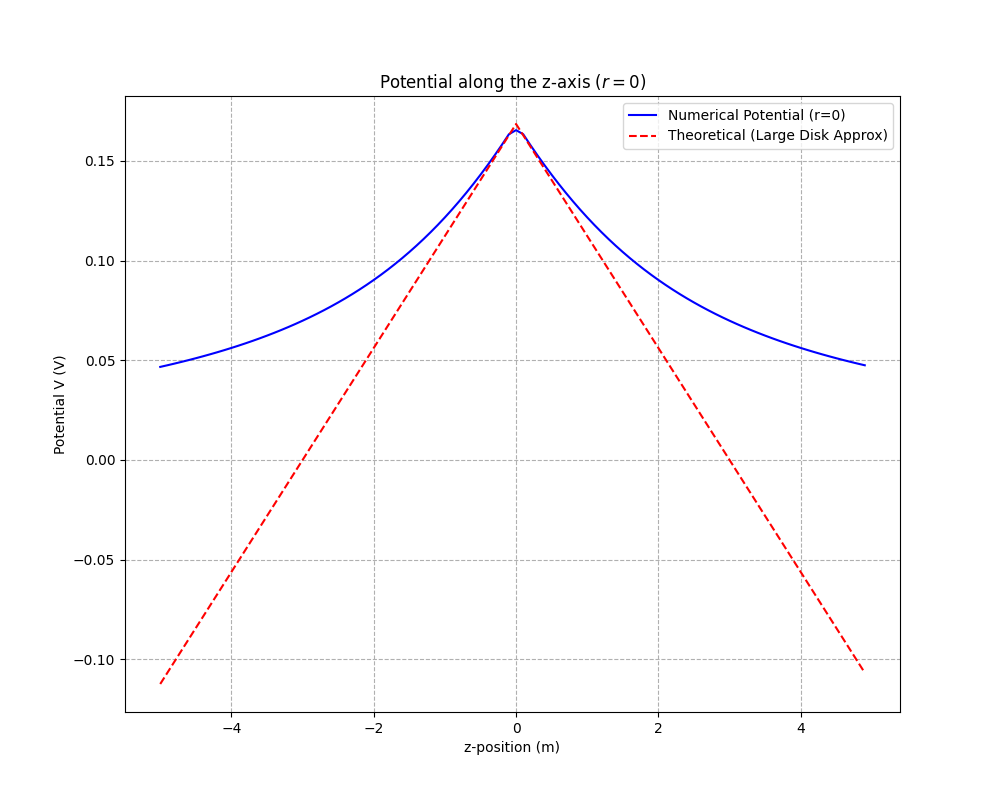

In [345]:

display(Image("vraag2e_plot.png"))
display(Image('vraag2e_plot_nieuwe_straal.png'))
display(Image('vraag2d_plot.png'))

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

- Field of the infinite plane: $E_{plane} = \frac{\sigma}{2\epsilon_0}$. Because the denominator becames so big, this equation $1- \frac{z}{\sqrt{R^2 + z^2}}$ becames 1-0. Resulting in  $\frac{\sigma}{2\epsilon_0}$.


- To find the 10%, we will use the equation below
$$E = 0.10 \cdot E_{plane}$$
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
$$  0.10 \cdot  \frac{\sigma}{2\epsilon_0} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$


- Simplifying the equation will give:
$$\frac{z}{\sqrt{R^2 + z^2}} = 0.90$$
- Insulating z would give:
$$z = \sqrt{\frac{0.81}{0.19}} \cdot R $$
$$ z \approx 2.06 \cdot R$$


- This shows that, by multiplying the raduis by roughly 2 would indicate the position where the electric field is 10%.



### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

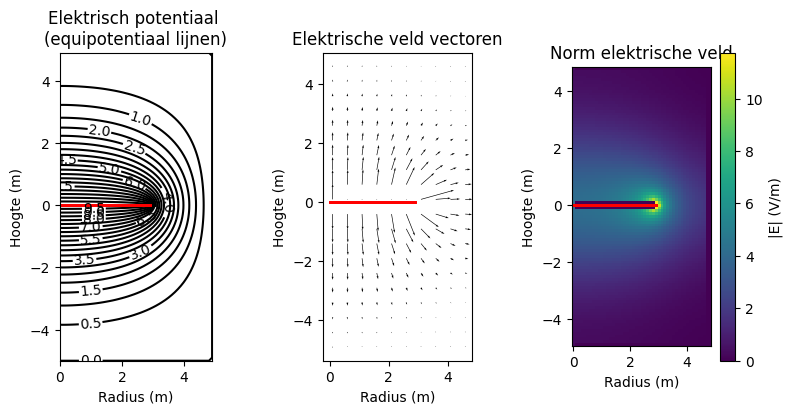

In [346]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

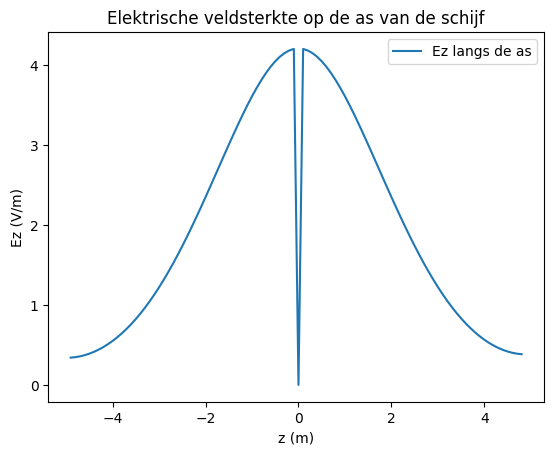

norm van het elektrische veld : 1.521e-05 V/m


In [347]:
import numpy as np
import matplotlib.pyplot as plt

# vind de kleinste waarde van r (dichtsbij de schijf)
idx_r0 = np.argmin(np.abs(r_for_E))  

# plotten
plt.figure()
plt.plot(z_for_E, normE[:,idx_r0], label="Ez langs de as")
plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("Elektrische veldsterkte op de as van de schijf")
plt.legend()
plt.show()

#  norm zoeken (waarde z die het dichts bij het midden van de schijf ligt, z≈0 )
idx_z0 = np.argmin(np.abs(z_for_E))
E_center = normE[idx_z0,idx_r0]


print(f"norm van het elektrische veld : {E_center:.3e} V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b
$$
σ(r)=ε_0​Ez​(r,z=0^+)
$$
$$
σ(0)=ε_0​Ez​(0,0^+)
$$

In [348]:
# Constante
epsilon0 = 8.854e-12  # F/m
Ez_center = Ez[idx_z0+1,0]

# Bereken oppervlakteladingsdichtheid σ

sigma_center = epsilon0 * Ez_center

print(f"Benadering van de oppervlakteladingsdichtheid in het midden van de schijf: {sigma_center:.3e} C/m²")

Benadering van de oppervlakteladingsdichtheid in het midden van de schijf: 3.720e-11 C/m²


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


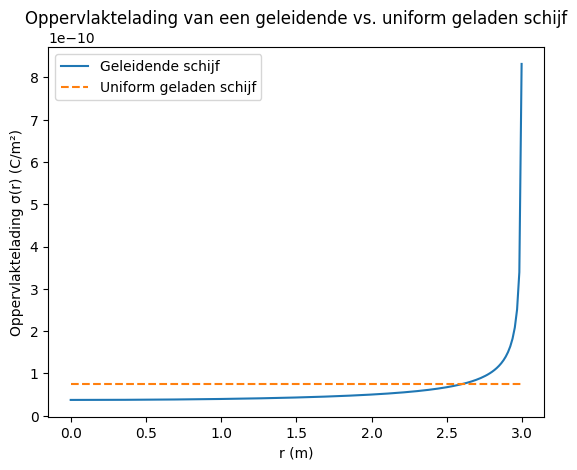

oppervlaktelading geleidende schijf: 3.720e-11
oppervlaktelading uniform: 7.441e-11
de ratio tussen sigma_geleidend en sigma_uniform: 0.5


In [349]:
 # straal van de schijf in meters
R = disk_radius      

# totale lading Q
Q = 2 * np.pi * R**2 * sigma_center # totale lading (uitlimiet bij r->0)

# R-waarden om sigma(r) te plotten
r_values = np.linspace(0, R*0.999, 200)

# Oppervlaktelading van geleidende schijf
sigma_conducting = Q / (2 * np.pi * R * np.sqrt(R**2 - r_values**2))

# Uniform geladen schijf
sigma_uniform = Q / (np.pi * R**2)

# Plot
plt.figure()
plt.plot(r_values, sigma_conducting, label="Geleidende schijf")
plt.plot(r_values, sigma_uniform*np.ones_like(r_values), '--', label="Uniform geladen schijf")
plt.xlabel("r (m)")
plt.ylabel("Oppervlaktelading σ(r) (C/m²)")
plt.title("Oppervlaktelading van een geleidende vs. uniform geladen schijf")
plt.legend()
plt.show()

# waarden printen
print(f"oppervlaktelading geleidende schijf: {sigma_center:.3e}")
print(f"oppervlaktelading uniform: {sigma_uniform:.3e}")
print(f"de ratio tussen sigma_geleidend en sigma_uniform: {sigma_center/sigma_uniform:.1f}")

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [350]:
# 1. Maximum van het veld
E_max = np.max(normE)

# 2. locatie van het maximum 
max_idx_flat = np.argmax(normE)
max_idx = np.unravel_index(max_idx_flat, normE.shape)
z_max = z_for_E[max_idx[0]]  
r_max = r_for_E[max_idx[1]]

# 3. verhouding maximum tot midden van de schijf 
verhoging = E_max / E_center

print(f"Maximum elektrisch veld: {E_max:.3e} V/m")
print(f"Locatie van maximum: r = {r_max:.3f} m, z = {z_max:.3f} m")
print(f"Verhouding maximum / midden: {verhoging:.2f}x")

Maximum elektrisch veld: 1.175e+01 V/m
Locatie van maximum: r = 3.000 m, z = 0.100 m
Verhouding maximum / midden: 772488.59x


##### Antwoord 3d.5
Het lokaal hoge veld ontstaat door het edge effect: de ladingen concentreren zich aan de rand van de geleidend schijf, waardoor het veld daar groter wordt dan in het midden

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

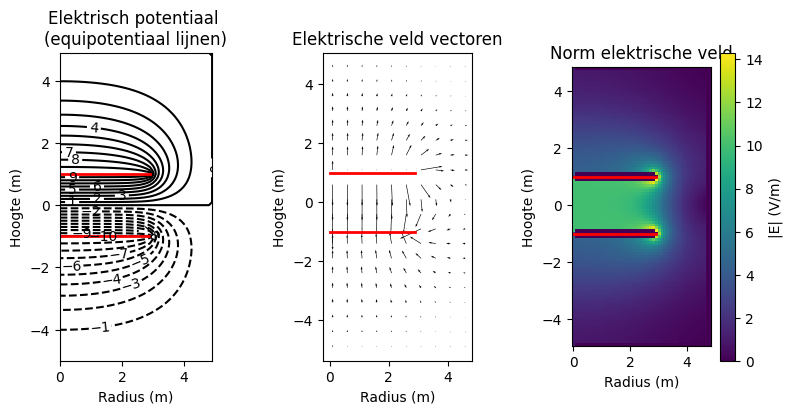

In [351]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


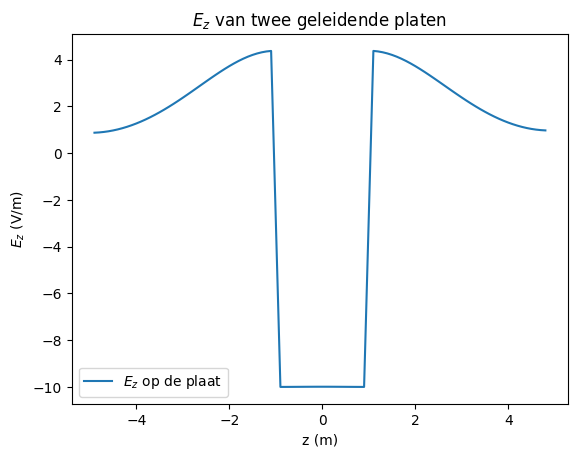

In [352]:
# waarde dichtsbij de plaat 
idx_r_zero = np.argmin(abs(r_for_E))

# selecteerd de as op de waarde dichtsbij plaat (idx_r_zero)
Ez_axis = Ez[:, idx_r_zero]

# plotten
plt.figure()
plt.plot(z_for_E, Ez_axis, label="$E_z$ op de plaat")
plt.xlabel("z (m)")
plt.ylabel("$E_z$ (V/m)")
plt.title("$E_z$ van twee geleidende platen")
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1) er is geen vrije lading in de ruimte er is alleen een elektrisch veld, dus geldt laplace. die zegt dat ∇²V = 0. Omdat alleen de z component verandert versimpelt dit naar d²V/dz² = 0. dit betekent dat het potentiaal linear veranderd (2 afgeleide is 0, 1 afgeleide is constant dus 0 afgeleide is linear), dus V(z)= az+b. Er is al bekend dat V(d/2)= 10 of -10. dit betekent dat a= 20/d of a=-20/d en b is 0 (z component is constant). Doordat de platen op 2m afstand staan volgt uit de berekening dat het veld een waarde heeft van 10 V/m. Het elektrische veld buiten de plaat is idealistisch gezien 0.  \
Dus tussen de platen is het veld 10V/m en buiten de platen is het veld 0 V/m.   
2) Binnen de platen klopt de theorie met het numeriek berekende veld, want de veldsterkte is tussen de platen -10 V/m. Buiten de platen zou volgens de theorie de veldsterkte 0 moeten zijn en die is volgende de numerieke berekening groter dan 0, die komen niet met elkaar overeen.
3) Bij een enkele schijf is het veld niet homogeen, maar tussen 2 schijfen is het veld ongeveer homogeen. De randeffecten bij 2 schijfen heffen elkaar gedeeltelijk op. Het veld op de as is bij 2 schijfen sterker dan bij 1 schijf (2 schijfen=10 en 1 schijf=4)



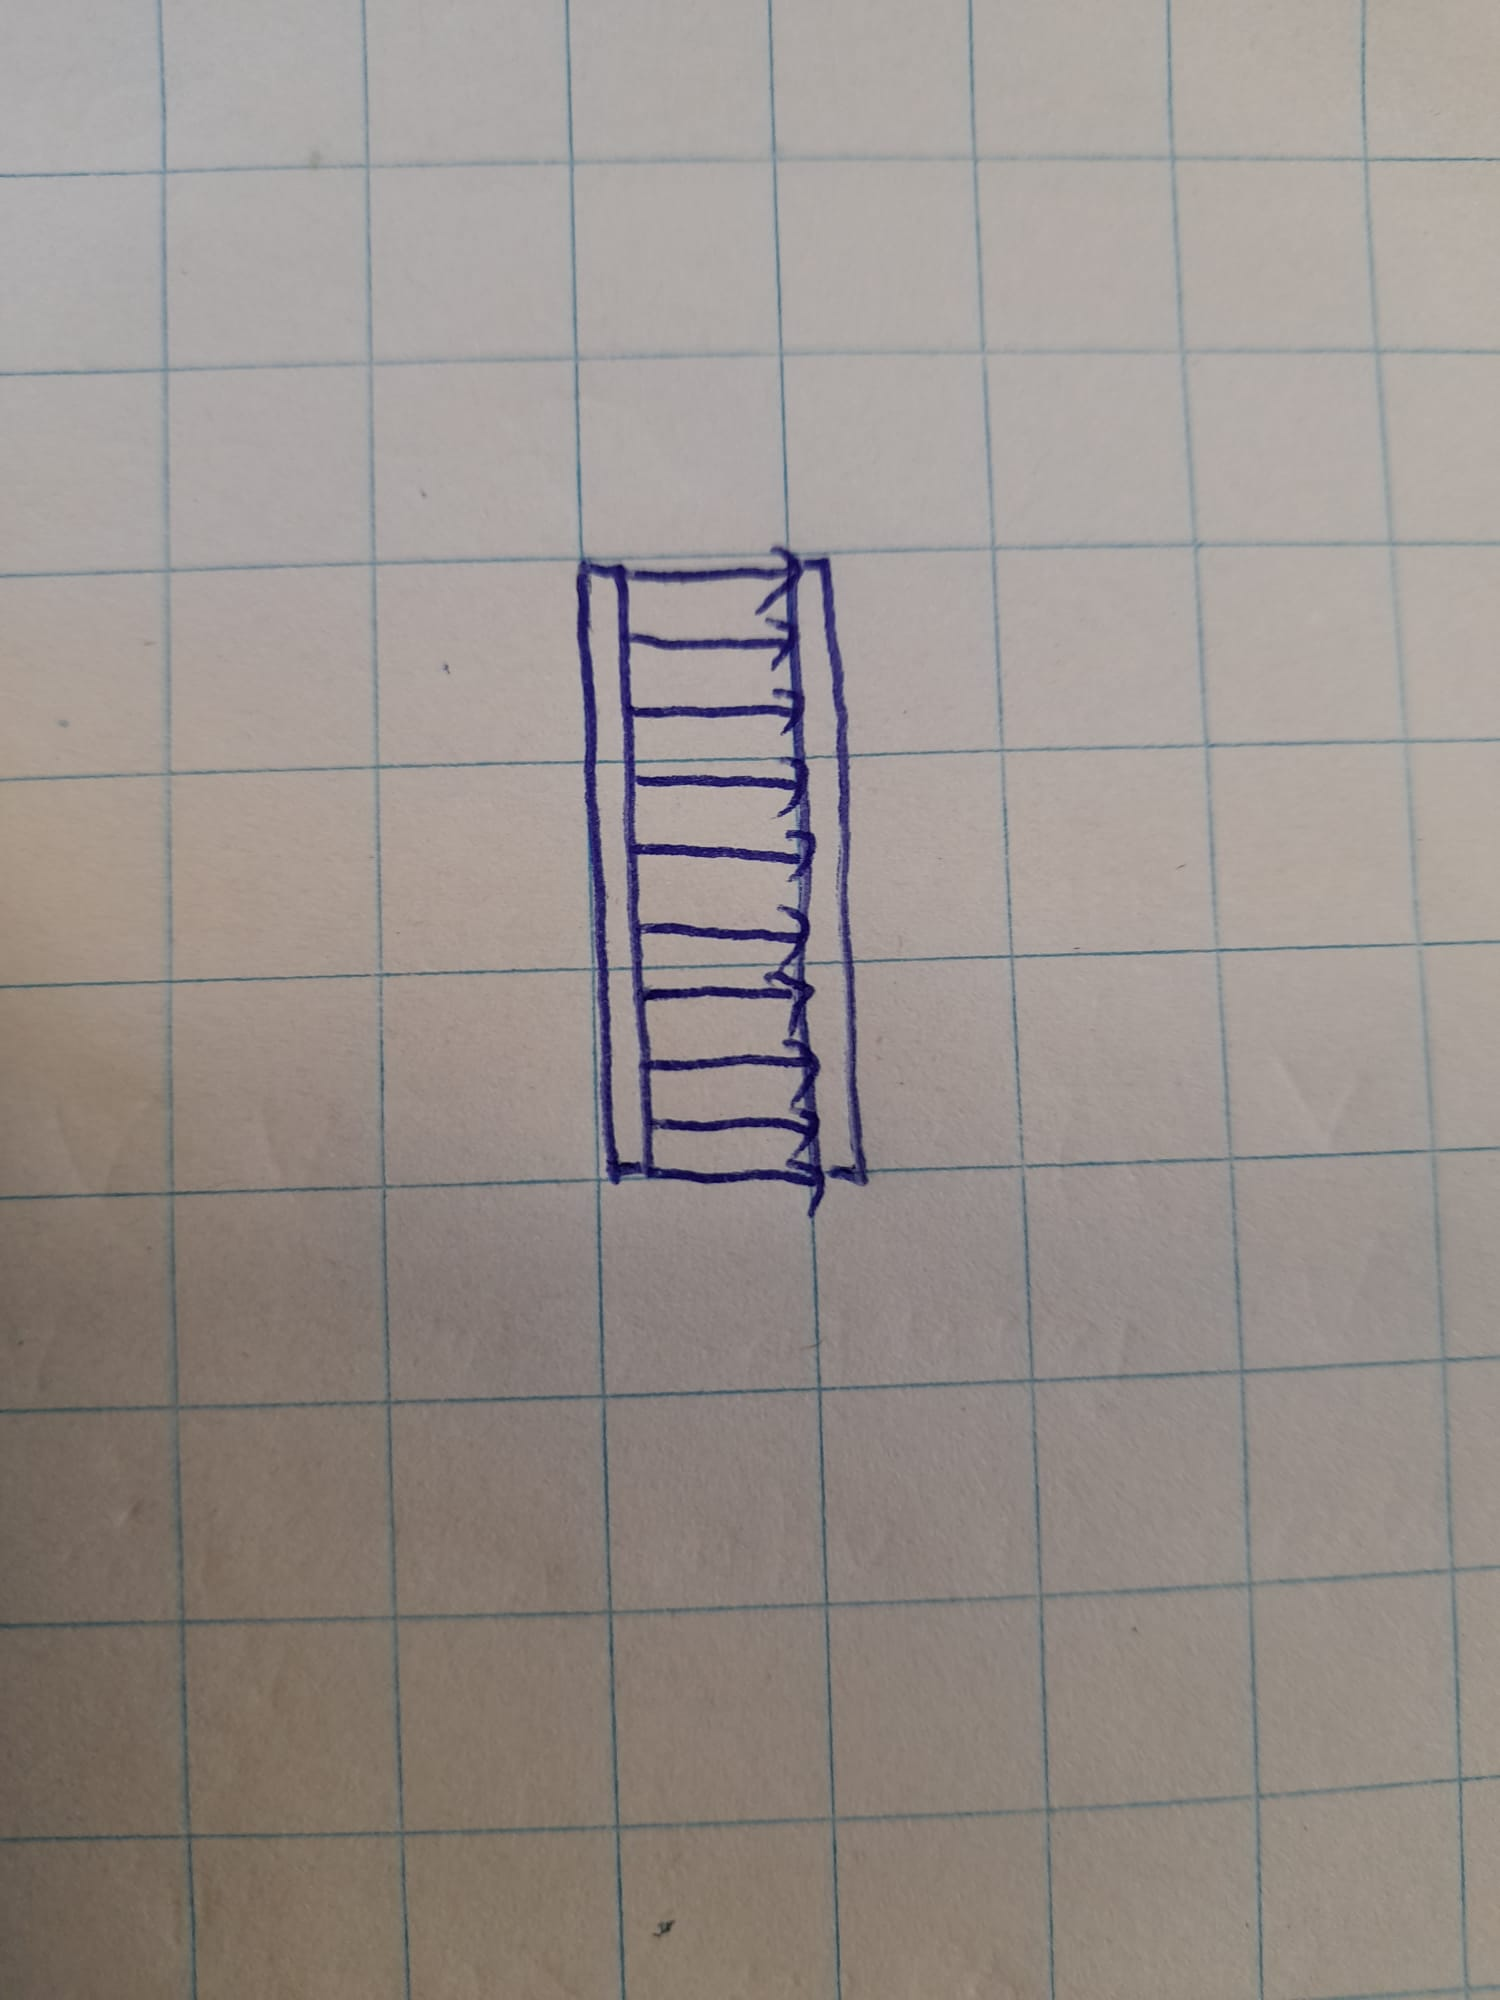

In [353]:
display(Image("schets_4b.jpeg"))

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [354]:
R = disk_radius  # straal van platen (m)
d = spacing_between_disks  # afstand tussen platen (m)
deltaV = V1-V2  # potentiaalverschil tussen platen (V)
eps0 = 8.854e-12  # permittiviteit vacuum (F/m)

# Oppervlakte van de plaat
A = np.pi * R**2

# Oppervlaktelading op binnenkant van de  plaat
sigma = eps0 * deltaV / d

# Totale lading op beide platen
Q = 2*sigma * A

# Capaciteit
C = Q / deltaV 

# resultaten
print(f"Oppervlaktelading op binnenzijde van een plaat: {sigma:.3e} C/m²")
print(f"Totale lading op beide platen: {Q:.3e} C")
print(f"Capaciteit van de condensator: {C:.3e} F")

Oppervlaktelading op binnenzijde van een plaat: 8.854e-11 C/m²
Totale lading op beide platen: 5.007e-09 C
Capaciteit van de condensator: 2.503e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d
 
1. In een idealistische situatie zou het veld aan de buitenkant van de schijven 0 zijn, wat als gevolg heeft dat de oppervlaktelading ook 0 is volgens onderstaande vergelijking. Doordat hier gerekend wordt met schijven met een eindige lengte kunnen de veldlijnen niet plotseling stoppen en heffen ze elkaar niet goed op aan de buitenkant. Een niet 0 veld betekent dat er zich een oppervlaktelading bevind (volgens onderstaande formule) en is de oppervlakte aan de buitenkant dus niet 0. $$(\sigma = \varepsilon_0 E_{\perp})$$
2. In elektrostatica geldt binnen een geleider dat het veld gelijk is aan 0. Als dit niet zo is kunnen elektronen zich vrij bewegen en is het systeem niet meer statisch. Uit de maxwell vergelijking volgt: $$E_{\perp,\text{buiten}} - E_{\perp,\text{binnen}} = \frac{\sigma}{\varepsilon_0}$$ 
doordat E_binnen=0 wordt de formule voor het veld buiten: $$E_{\perp,\text{buiten}}= \frac{\sigma}{\varepsilon_0}$$ 

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [370]:
epsilon0 = 8.854e-12  # F/m

idx_disk2 = np.argmin(np.abs(z_for_E - z_pos_disk2))

# Zoek index net onder en net boven de onderste schijf
Ez_below = Ez[idx_disk2 -1,idx_r0]
Ez_above = Ez[idx_disk2 +1,idx_r0]


# Oppervlakteladingsdichtheid via formule
sigma_bottom = epsilon0 * Ez_below
sigma_top = epsilon0 * Ez_above

print(f"Ez net onder de onderste schijf = {Ez_below:.3e} V/m")
print(f"Oppervlaktelading onderkant = {sigma_bottom:.3e} C/m^2")
print()
print(f"Ez net boven de onderste schijf = {Ez_above:.3e} V/m")
print(f"Oppervlaktelading bovenkant= {sigma_top:.3e} C/m^2")

Ez net onder de onderste schijf = 4.377e+00 V/m
Oppervlaktelading onderkant = 3.875e-11 C/m^2

Ez net boven de onderste schijf = -1.000e+01 V/m
Oppervlaktelading bovenkant= -8.858e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f
1. Bij vraag 4c is verondersteld dat alle ladingen zich aan de binnenkant van de plaat bevinden en dat het veld aan de buitenkant 0 is. Dit is echter niet het geval: er bevind zich wel lading aan de buitenkant van de plaat, waardoor er wel een veld is. Dus de werkelijke ladingsverdeling wijkt af van de ideale benadering en niet alle lading draagt bij aan het veld tussen de platen.
2. In vraag 4c wordt ervan uitgegaan dat het veld zich volledig tussen de platen bevind en er geen randvelden zijn. Dit is echter niet het geval en doordat er wel randvelden zijn is de capaciteit in de werkelijke situatie zelfs groter dan de ideale situatie, omdat de randvelden ervoor zorgen dat er ook energie wordt opgeslagen net buiten de platen (dus A is groter en dus C is groter).
3. Het veld wordt sterker naarmate de platen dichter bij elkaar komen. Als de platen dichter bij elkaar zijn doen de randvelden er minder toe, bevind de lading zich meer aan de binnenkant van de plaat en is het veld homogener. Dit alle zorgt ervoor dat het veld sterker wordt en de capaciteit groter. 


### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

###### Answer Question 5a
- The capacitance ($C$) of a parallel plate could be found using the equation: $$C = \epsilon_0 \frac{A}{d}$$. The area in the eqaution gives us a hint that, the shape or form of the capacitor could be changed. By substituting the normal area of rectangle with that of a circle, the equation becames: $$C = \epsilon_0 \frac{\pi R^2}{d}$$

- Because a cylinder has a side with a radius and a side with different length (Not equal to the radius), the $R^2$ needs to be the handled like a rectangle, with radius as the width and the height of the cylinder as it breadth. With this, the equation became: $$C = \epsilon_0 \frac{\pi R L}{d}$$. Hereby, has the area become : $ A = \pi R L $. However, cylindrical capacitors have inner radius and outer radius separated by the two radii. Also the part of interest of the cylinder is the outer part. Therefore, we are not really interested in the area od the cylinder, but it circumference. The circumference of a circle is just $ 2\pi R$. By simply add a 2 to the equation, it gets the form : $$C = \epsilon_0 \frac{2\pi R L}{d}$$    



In [356]:
def vlakkeplaat(area_p,distance_p, permi): # Based on the equation, the only arguments needed are the area and the distance. 
    C = (permi*area_p)/distance_p
    return (C) # By filling in the area and the distance of a parallel plate capacitor, the output value will be capacitance.

def cilinder(radius_c,length_c,distance_c,permi_c): # From the equation above, the only non-constant values are the distance, the radius and the length.
    Cc= (2*permi_c*np.pi*radius_c*length_c)/distance_c
    return  (Cc)

#Also there is a much precise way to find the capacitance of a cylinder.
#We substitute the d with the natural log. Where within the outer and inner radius is used.
def al_cilinder(r_out,r_in,length_al,permi_al):
    top=2*np.pi*length_al*permi_al
    denominator= np.log(r_out/r_in)
    result= top/denominator
    return(result)



#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


##### Answer Question 5b: Extra Information 
The relative permittivity has the following equation: $$\epsilon_r = \frac{\epsilon}{\epsilon_0}$$
This is used to compare a capacitor's capacitance in a vacuum with other substances. 

 


In [357]:
# Q1) It is a square with values of 10cm (0.1m). Also, it distance is 1mm(0.001m) and a relative permittivity of air
area_square = 0.1*0.1 #m
distance_square =0.001 #m
r_permittivity_air = 1.0006 #m 
#Since the relative permittivity is roughly 1, we simple use the standard vacuum permittivity.
result_question_1 = vlakkeplaat(area_square,distance_square,epsilon0)
print('Capacitance value for question 1:',result_question_1)

# Q2) It is cylinder with inner radius of 9mm and an outer radius of 10mm with a length of 10cm.
# Here the medium is again air, so the permittivity remains the same.
inner_radius_q2 = 0.009 #m
outer_radius_q2 = 0.01 #m
length_q2 = 0.1 #m
result_q2 = al_cilinder(outer_radius_q2,inner_radius_q2,length_q2,epsilon0)
print('Capacitance value for question 2:',result_q2)

#Q3) By doubling the plates distance, the denominator increases by 2 times
doubled_distance = 2*distance_square
result_q3 = vlakkeplaat(area_square,doubled_distance,epsilon0)
print('Capacitance value for question 3:', result_q3)

# Q4) The relative permittivity changes due to using water. Water has roughly a relative permittivity of 80.10 at room temperature (according to engineering ToolBox)
# To find the answer to the question, we simple multiply the relative permittivity by the value of capacitance found in een vacuum.
#Since the relative permittivity of air is roughly the same of as a vacuum, we simply stick to the found values of question 1.
def new_cap(cap_air,r_epi):
    result_new_cap = cap_air *r_epi
    return(result_new_cap)
#calculating
Relative_epi_water = 80.1
value_question_1 = result_question_1
result_q4_1 = new_cap(value_question_1,Relative_epi_water)
value_question_2 = result_q2
result_q4_2 = new_cap(value_question_2,Relative_epi_water)
print('Q4)New Capacitance value for question 1 :',result_q4_1)
print('Q4)New Capacitance value for question 2 :', result_q4_2)


#Q5) We use the same equation and functions from question 4. However the relative permittivity of a PVC is between 2 and 4. So we use the average.
relative_epi_PVC=(2+4)/2 
new_cap_q1 = new_cap(value_question_1,relative_epi_PVC)
new_cap_q2 = new_cap(value_question_2,relative_epi_PVC)

print('Q5)New capacitance value for questio 1:',new_cap_q1)
print('Q5)New capacitance value for question 2:',new_cap_q2)

Capacitance value for question 1: 8.854e-11
Capacitance value for question 2: 5.280092106841892e-11
Capacitance value for question 3: 4.427e-11
Q4)New Capacitance value for question 1 : 7.092054e-09
Q4)New Capacitance value for question 2 : 4.229353777580355e-09
Q5)New capacitance value for questio 1: 2.6562e-10
Q5)New capacitance value for question 2: 1.5840276320525677e-10


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

###### Answer question 5c
- 1 microfarad is : 0.000001 Farads


- The equation needs to be rewritten to find the length of the capacitor. $$C = \epsilon_0 \frac{2\pi R L}{d}$$. Keep in mind that the denominator could be rewritten using the natural log; $$C = \frac{2\pi \epsilon_0 L}{\ln(R_o / R_i)}$$. Isolating the length of a cylinderical capacitor: $$L = \frac{C \cdot \ln(R_o / R_i)}{2\pi \epsilon_0}$$

- For a parallel capacitor the length can be found by first expanding the area ($A= Length*Width$). This makes the capacitance equation become: $$C = \frac{\epsilon_0 (L \cdot W)}{d}$$. By free the L the equation becomes: $$L = \frac{C \cdot d}{\epsilon_0 \cdot W}$$

In [358]:
#First Question
#Since the condensator is out, we assume it permittivity will be that of air (roughly equal to a vacuum).
def Length_1(Ca,R_i,R_o):
    numerator=Ca*np.log(R_o/R_i)
    deno= 2*np.pi*epsilon0
    result_ca= numerator/deno
    return(result_ca)
# Details:
cap_q5c = 0.000001 #Farads
r_inner = 0.005 #m
r_outer = 0.006 #m

ans1=Length_1(cap_q5c,r_inner,r_outer)
print('This is the answer to the first question:',ans1)

#Second Question
def Length_2(ca,dis,wid):
    top2=ca*dis
    down2=epsilon0*wid
    res2=top2/down2
    return(res2)
#Details 
distance_plate =0.5/1000 #m
Width_plate = 0.006 #m
cap_q5c = 0.000001 #Farads
ans2= Length_2(cap_q5c,distance_plate,Width_plate)
print(f'This is the answer to the second question:',ans2)


This is the answer to the first question: 3277.3183867142097
This is the answer to the second question: 9411.941871847


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d
1) The answers found do not seem to be very realistic due to how small capacitors in real life are. In real life, they are not longer than a few millimeters. Therefore, having the values of $3.2km$ and $9.4km$ does not reflect what we produce in real life.

2) - The first solution is to stack as many thin metal layers on top of each other and connect them in parallel. This will result in a smaller distance with a large area.
   - Second, making use of a volume: We could change the long straight shape into a cylindrical form.  This will create a volume that could contain more thin metal, and also increase the area which affect the overall performance positively. 
   - Finally, by using a higher relative permittivity. A higher permittivity would increase the denominator in both equations $L = \frac{C \cdot \ln(R_o / R_i)}{2\pi \epsilon_0}$ and $L = \frac{C \cdot d}{\epsilon_0 \cdot W}$ resulting in a decrease in the distance.     


#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [359]:
# 1. schatten van massa van treintje 
m_p = 70  # kg per persoon
n_p = 6   # personen per treintje
m_k = 200 # kg per treintje 
m_t = m_p*n_p+m_k #massa treintje

# 2. bereken de energie van het treintje 
v = 70/3.6 # van km/h naar m/s

E_kin = 0.5*m_t*v**2

# 3. capaciteit van de condensator
V = 10000 #10kV
C = 2*E_kin/V**2

# 4. 
epsilon_r_water = 80
epsilon_0 = 8.854e-12
d = 0.001  # m

A = (C*d)/(epsilon_r_water*epsilon_0)

# antwoorden printen 
print(f"massa van 1 treintje = {m_t:.1f} kg")
print(f"de totale energie van het karretje = {E_kin:.1f} J")
print(f"de capaciteit van de condensator = {C:.5f}F")
print(f"oppervlakte van vlakke plaat condensator: {A:.2f} m^2")

massa van 1 treintje = 620.0 kg
de totale energie van het karretje = 117206.8 J
de capaciteit van de condensator = 0.00234F
oppervlakte van vlakke plaat condensator: 3309.43 m^2


##### Antwoorden 5e

*Edit deze markdown cel met jouw idee hoe de capaciteit toch zo hoog kan zijn.*

De capaciteit is in dit geval toch nog best hoog. Naar de formule kijkend wordt de capaciteit alleen beinvloed door de kinetische energie en het voltage waarop de condensator opereert. De kinetische energie is best hoog vanwege het grote gewicht van het treintje en de voltage die erover staat is ook redelijk hoog. Dit is een reden waardoor de capaciteit toch redelijk hoog is.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

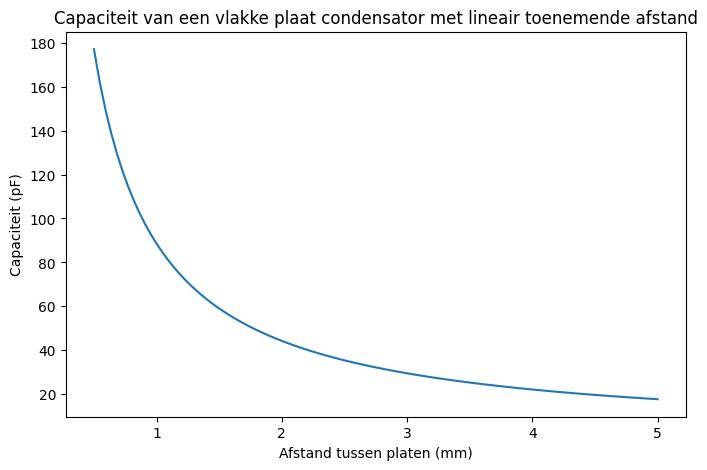

C:\Users\Lars\AppData\Local\Temp\ipykernel_18076\2015109791.py:9: RuntimeWarning: divide by zero encountered in divide
  return 2 * np.pi * epsilon_0 * epsilon_r * L / np.log(r_outer/r_inner)


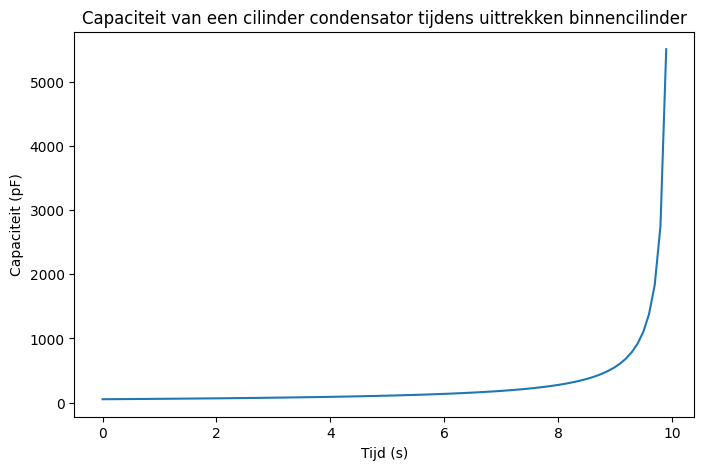

In [360]:
# Constante
epsilon_0 = 8.854e-12  # vacuum permittiviteit (F/m)

# opnieuw functies definiëren van 5a 
def vlakkeplaat(A, d, epsilon_r=1):
    return epsilon_0 * epsilon_r * A / d

def cilinder(r_inner, r_outer, L, epsilon_r=1):
    return 2 * np.pi * epsilon_0 * epsilon_r * L / np.log(r_outer/r_inner)

# 1. capaciteit van vlakke plaat condensator bij linear toenemende afstand 
A_plate = 0.10 * 0.10  # 10cm x 10cm
d_start = 0.5e-3       # 0.5 mm
d_end = 5e-3          # 5 mm

# lineair variërende afstand
d_values = np.linspace(d_start, d_end, 100)
C_plate = vlakkeplaat(A_plate, d_values, epsilon_r=1)

# Plot 1
plt.figure(figsize=(8,5))
plt.plot(d_values*1e3, C_plate*1e12)  # x in mm, C in pF
plt.xlabel("Afstand tussen platen (mm)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit van een vlakke plaat condensator met lineair toenemende afstand")
plt.show()

# 2. capaciteit van condensator met uitgetrokken binncilinder
r_inner_start = 0.009    # 9 mm
r_inner_end = 0.010      # 10 mm (uitgetrokken)
r_outer = 0.010          # 10 mm
L = 0.10                 # 10 cm

# tijd in seconden
t = np.linspace(0, 10, 100)
r_inner_values = np.linspace(r_inner_start, r_inner_end, len(t))
C_cyl = cilinder(r_inner_values, r_outer, L, epsilon_r=1)

# plot 2 
plt.figure(figsize=(8,5))
plt.plot(t, C_cyl*1e12) 
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (pF)")
plt.title("Capaciteit van een cilinder condensator tijdens uittrekken binnencilinder")
plt.show()


## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [361]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [362]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1.1

 bij de afleiding hieronder worden de volgende aannamens gemaakt: 
1) de platen worden als vlak en parallel beschouwd, hierdoor is het veld tussen de platen homogeen en loodrecht op de platen
2) hoewel de plaat maar 10x10cm is, is de afstand tussen de platen aanzienlijk veel kleiner dan de oppervlakte van de plaat. Door deze reden mogen edge effects verwaarloosd worden in het midden van de plaat.
3) de grote van het veld is overal hetzelfde en loopt overal loodrecht op de recht
4) op de oppervlakteladingsdichtheid (σ) is overal constant
5) invloeden van een ander D-veld buiten de plaat wordt verwaarloosd, omdat het D-veld tussen de platen veel dominerender is
![afleiding_Dveld1](afleiding_Dveld.jpeg)

##### antwoord 6c 1.2
Definitie D-veld 
$$
1) \mathbf{D} = \varepsilon_0 \mathbf{E} + \mathbf{P}
$$
Een niet lineare polarisatie geeft:
$$
2) \mathbf{P} = \varepsilon_0 (\chi_1 \mathbf{E} + \chi_2 \mathbf{E}^2)
$$
P invullen in D
$$
3) D = \varepsilon_0 (1+\chi_1) E + \varepsilon_0 \chi_2 E^2
$$
Omschrijven naar een kwadratische vergelijking
$$
4) \chi_2 E^2 + (1+\chi_1) E - \frac{D}{\varepsilon_0} = 0
$$
abc-formule toepassen 
$$
5) E = \frac{-(1+\chi_1) \pm \sqrt{(1+\chi_1)^2 + 4 \chi_2 \frac{D}{\varepsilon_0}}}{2 \chi_2}
$$
Het D-veld moet in dezelfde richting staan als het E-veld en dat resulteert dat de - wortel een foute oplossing is en de volgende vergelijking overblijft voor E
$$
6) \mathbf{E} = \frac{-(1+\chi_1) + \sqrt{(1+\chi_1)^2 + 4 \chi_2 D / \varepsilon_0}}{2 \chi_2} \, \hat{n}
$$

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

The Fitted Results
The slope of a_val:           9.7050e-12 F/kg
The starting value of b_val:  1.2066e-11 F


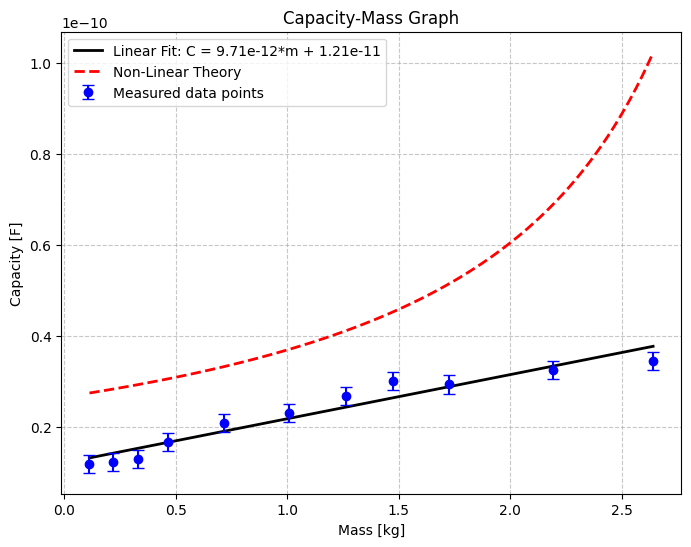

In [363]:
from scipy.optimize import curve_fit

# Measured Data
gravity = 9.81 # m/s^2
mass = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627])
F = mass * gravity # Standard equation of a force in one direction 
Capa_values = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8]) * 1e-12


# Constant Values
epsilon_0 = 8.854e-12 # F/m
Area = 0.01 # The area of a plate in m^2
d_0 = 0.01 # The initial distance between the two plates in m
k_veer = 3500 # Resistance/Foam constant in N/m
delta_V = 5 # Applied voltage

# Foam parameters
xf1 = 2.0           
xf2 = 3e-10          

# Defining equations to be fitted later
def fitting(x_values, slope, starting_value):
    return (slope * x_values) + starting_value

def nonlinear_theoretical_model(mass):
    #Calculate the new distance due to compression for each mass
    d_dynamic = d_0 - (((mass) * gravity) / k_veer)
    
    # To prevent division by 0 we used this code
    if np.any(d_dynamic <= 0):
        raise ValueError("The applied mass compresses the capacitor completely (d <= 0).")

    #Calculates the Electric field (E = V/d)
    E_field = delta_V / d_dynamic
    
    #Calculates the Displacement field (D) for a non-linear dielectric
    D_field = epsilon_0 * ((1 + xf1) * E_field + xf2 * (E_field**2))
    
    #Calculate the capacity (C = (D * A) / V)
    C_theory = (D_field * Area) / delta_V
    return C_theory

#Now that all function have been defined,, we proceed to fitting.

# Fitting the measured data 
popt, pcov = curve_fit(fitting, mass, Capa_values)
a_val, b_val = popt

print("The Fitted Results")
print(f"The slope of a_val:           {a_val:.4e} F/kg")
print(f"The starting value of b_val:  {b_val:.4e} F")

# Making python make values to be used for the gained slope and start value 
mass_clean = np.linspace(min(mass), max(mass), 100)
capacity_clean = fitting(mass_clean, a_val, b_val)
capacity_theory_line = nonlinear_theoretical_model(mass_clean)

#Now we plot

y_error = 2e-12
plt.figure(figsize=(8,6))

# Error bars plot
plt.errorbar(mass, Capa_values, yerr=y_error, fmt='o', color='b', capsize=4, label='Measured data points', zorder=5)

# Plotting the fit curve
plt.plot(mass_clean, capacity_clean, color='k', label=f'Linear Fit: C = {a_val:.2e}*m + {b_val:.2e}', linewidth=2)

# Theoretical non-linear curve
plt.plot(mass_clean, capacity_theory_line, color='r', linestyle='--', label='Non-Linear Theory', linewidth=2)

plt.title('Capacity-Mass Graph')
plt.xlabel('Mass [kg]')
plt.ylabel('Capacity [F]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Analyzing the graph
1) Based on the graph the theoretical model has a higher start value than that of the linear fit. This is due imperfections in the general build up or set-up of the meting instrument (capacitive/sensor). Using the formula ($C_0 = \frac{\varepsilon_0 \varepsilon_r A}{d_0}$), the distance between the plates might have been measured or estimated wrongly which might have led to this outcome. 

2) The measured data does not follow the predicted motion of the theoretical model. The main issue here is that the assumed stiffness (spring constant) of the foam used in the theoretical calculations is too low. The mathematical model assumes the foam is very soft, calculating a massive compression. For example assuming the plates shrink by 10 mm when they actually only shrink by 1 mm. This results in a much larger theoretical capacity. Additionally, based on the physical experiment (the photo of the setup), there seems to be a mixture of air and foam between the plates. This composite material significantly affects the actual stiffness and permittivity compared to the idealized model.


3) The non-linear theory shows an accelerating curve as the mass increases, which deviates completely from the linear trend of the measured values. Because the theoretical model assumes the foam compresses too easily, the calculated distance ($d$) between the plates becomes very small. This artificially causes the theoretical electric field ($E = \frac{\Delta V}{d}$) to increase massively. This extreme E-field then triggers the non-linear susceptibility term ($\chi_2 E^2$) in the code, compounding the upward curve. In reality, the actual foam is stiff enough that the distance between the plates never gets small enough to generate the intense electric fields required to trigger such non-linear behavior.



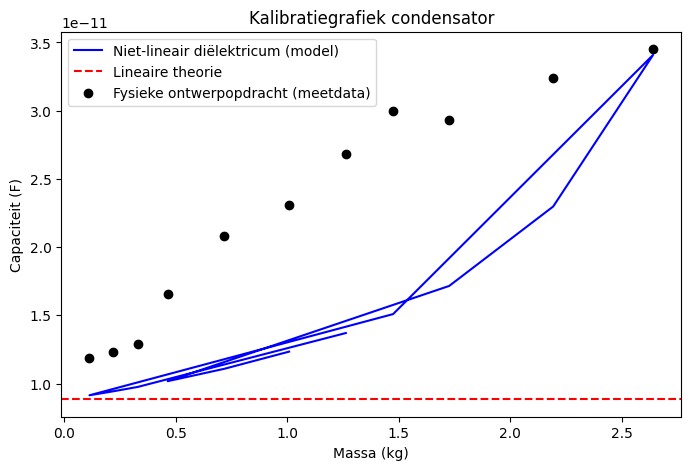

In [364]:

# This is code and fit made during week 3 experiment 2 on Wednesday 25th. This could be used as reference to check the final result printed above this code cell.
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTEN
eps0 = 8.854e-12
A = 0.1*0.1
d0 = 0.01
g = 9.81
k = 3500
DeltaV = 5

# MASSA
massa = np.array([1.0083, 0.7181, 0.4637, 1.7264, 2.1929, 2.641, 1.4748, 0.1127, 0.2164, 0.3291, 1.2627])
F = massa * g

# PLAATAFSTAND MET COMPRESSIE
d = d0 - F/k
d = np.maximum(d, 0.001)  # voorkom negatieve afstand

# LINEAIR E VELD
E_linear = DeltaV / d

# Parameters spons
x1 = 0.2
x2 = 3e-10

# D VELD
D = eps0 * ((1 + x1)*E_linear + x2*E_linear**2)

# Functie om E uit D te berekenen
def E_condensator(D, x1=0.2, x2=3e-10):
    eps0 = 8.854e-12
    a = x2
    b = 1 + x1
    c = - D / eps0
    E = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    return E

# NIET-LINEAIR E VELD
E_nl = E_condensator(D, x1, x2)

# Capaciteit
C_nl = (A * eps0 * E_nl) / DeltaV
C_lin = (A * eps0) / d0

# Meetdata
C_meet = np.array([23.1, 20.8, 16.6, 29.3, 32.4, 34.5, 30, 11.9, 12.3, 12.9, 26.8])*1e-12

# Plot
plt.figure(figsize=(8,5))
plt.plot(massa, C_nl, label="Niet-lineair diëlektricum (model)", color='blue')
plt.axhline(C_lin, color='red', linestyle='--', label="Lineaire theorie")
plt.scatter(massa, C_meet, color='black', label="Fysieke ontwerpopdracht (meetdata)")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.title("Kalibratiegrafiek condensator")
plt.legend()
plt.show()

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*